# EDA — Antennes Relais Paris
Analyse exploratoire des antennes relais par arrondissement, opérateur et type de réseau.

In [3]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

with open('../brute/Score-de-connectivite/2026-05-29/antennes-relais.json', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data['records'])
df.columns = df.columns.str.strip()
print(f'Shape brute : {df.shape}')
df.head(3)

Shape brute : (2170, 12)


,code_site,adresse,ardt,operateur,type,mise_en_serv,mise_en_serv_4g,mise_en_serv_5g_3500,mise_en_serv_5g_700,se_anno_cad_data,geo_shape,geo_point_2d
0,751293,157 Boulevard davout,75020,SFR,2G/3G/4G/5G,2021-08-25,None,None,None,None,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.409272999948469, 'lat': 48.859587000..."
1,75119_003_01,159 Avenue de flandres,75019,FREE MOBILE,3G/4G/5G,2013-09-16,2013-09-16,2023-07-18,None,None,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.3804280000076177, 'lat': 48.89376900..."
2,75107_036_03,16 Rue barbet de jouy,75007,FREE MOBILE,3G/4G/5G,2017-12-18,2017-12-18,2023-05-19,None,None,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.317664746391155, 'lat': 48.854072138..."


## 1. Vue générale

In [4]:
print('Colonnes :')
print(df.columns.tolist())
print(f'\nLignes   : {len(df):,}')
print(f'Colonnes : {df.shape[1]}')

Colonnes :
['code_site', 'adresse', 'ardt', 'operateur', 'type', 'mise_en_serv', 'mise_en_serv_4g', 'mise_en_serv_5g_3500', 'mise_en_serv_5g_700', 'se_anno_cad_data', 'geo_shape', 'geo_point_2d']

Lignes   : 2,170
Colonnes : 12


## 2. Valeurs manquantes

Colonnes avec valeurs manquantes :
mise_en_serv_5g_700     2170
se_anno_cad_data        2170
mise_en_serv_5g_3500    1382
mise_en_serv_4g         1106
type                     587
mise_en_serv             121
dtype: int64


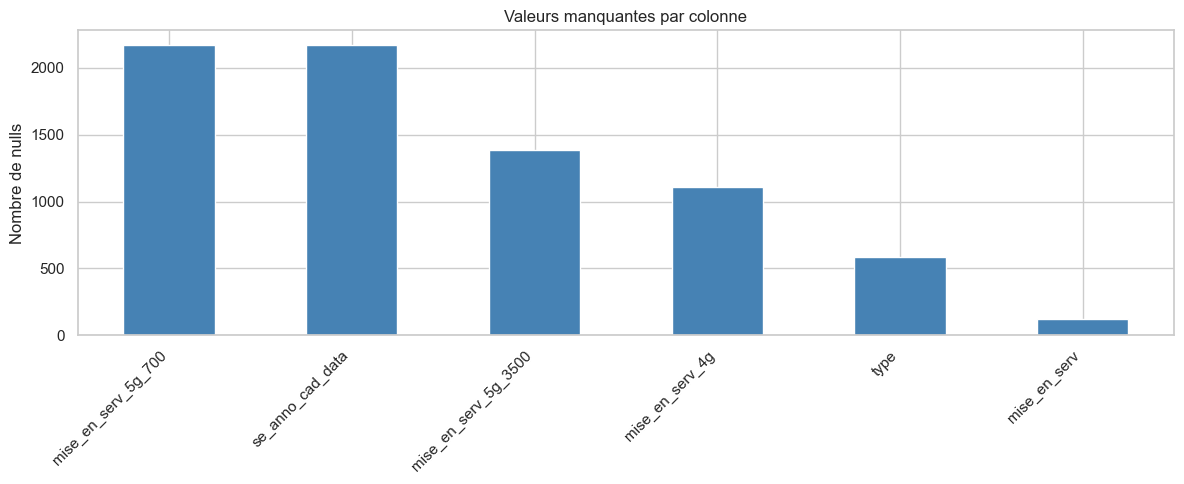

In [5]:
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
print('Colonnes avec valeurs manquantes :')
print(nulls)

ax = nulls.plot(kind='bar', color='steelblue')
ax.set_title('Valeurs manquantes par colonne')
ax.set_ylabel('Nombre de nulls')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Doublons

In [6]:
doublons = df.duplicated(subset=['code_site']).sum()
print(f'Doublons sur code_site : {doublons}')
print(f'Antennes uniques       : {len(df) - doublons:,}')

Doublons sur code_site : 0
Antennes uniques       : 2,170


## 4. Distribution par opérateur

operateur
FREE MOBILE    599
BOUYGUES       587
SFR            518
ORANGE         466
Name: count, dtype: int64


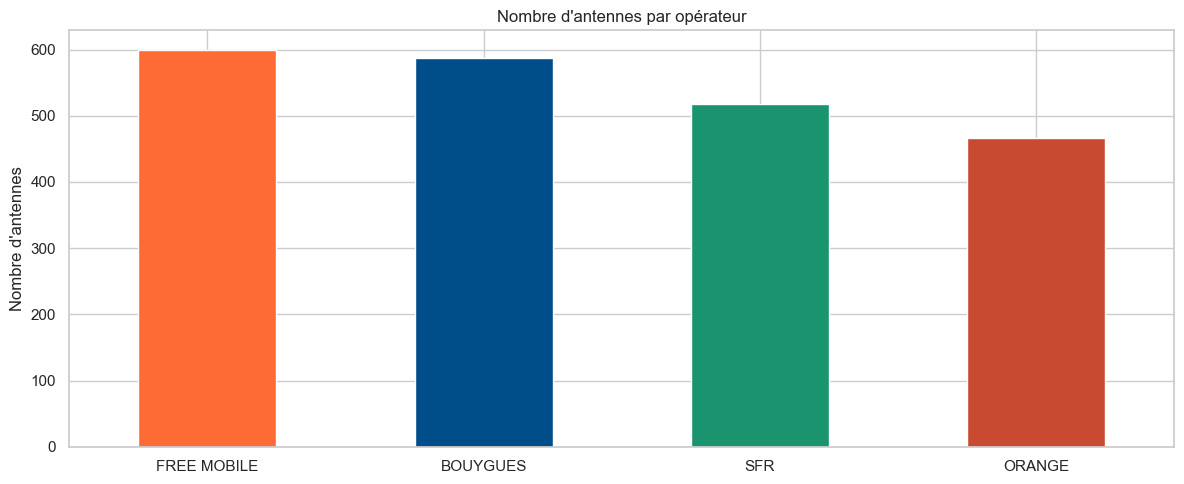

In [7]:
# Normalisation de la casse (Free Mobile vs FREE MOBILE)
df['operateur'] = df['operateur'].str.upper().str.strip()

op_counts = df['operateur'].value_counts()
print(op_counts)

ax = op_counts.plot(kind='bar', color=['#FF6B35', '#004E89', '#1A936F', '#C84B31'])
ax.set_title('Nombre d\'antennes par opérateur')
ax.set_xlabel('')
ax.set_ylabel('Nombre d\'antennes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Distribution par type de réseau

type
3G/4G/5G         1101
NON RENSEIGNÉ     587
2G/3G/4G/5G       273
2G/3G/4G          108
3G/4G             100
2G/3G               1
Name: count, dtype: int64


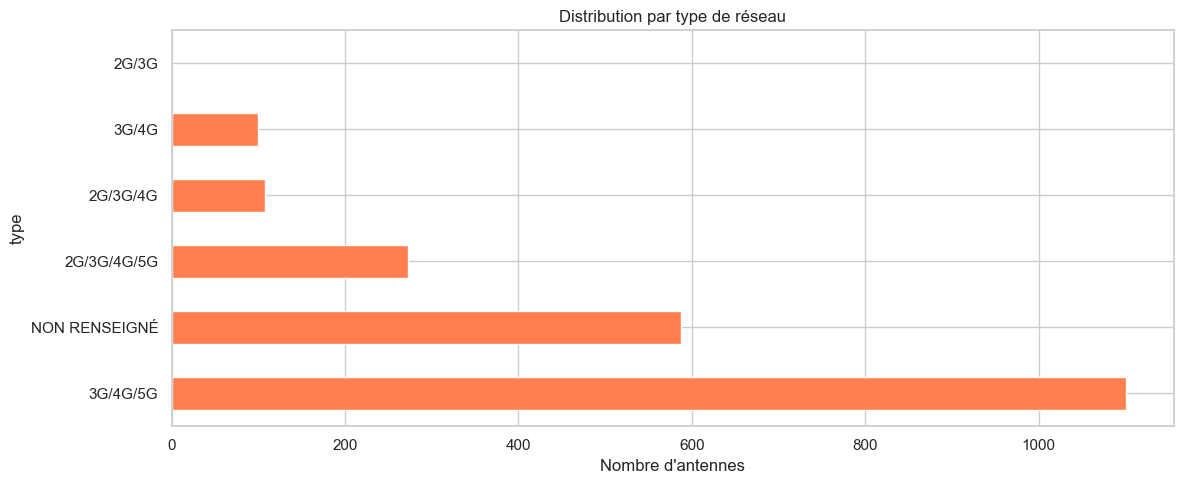

In [8]:
type_counts = df['type'].fillna('NON RENSEIGNÉ').value_counts()
print(type_counts)

ax = type_counts.plot(kind='barh', color='coral')
ax.set_title('Distribution par type de réseau')
ax.set_xlabel('Nombre d\'antennes')
plt.tight_layout()
plt.show()

## 6. Distribution par arrondissement

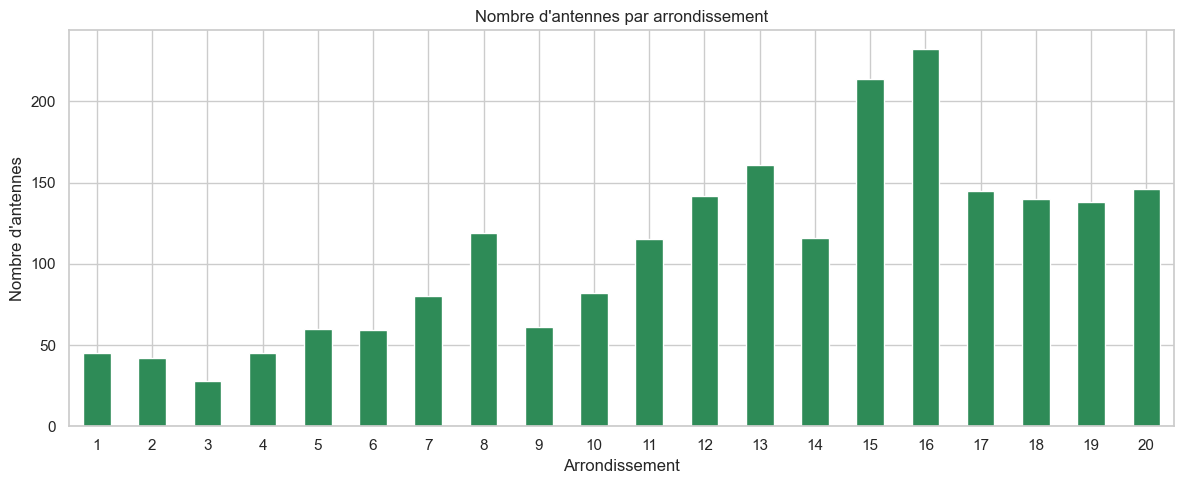

arrondissement
1      45
2      42
3      28
4      45
5      60
6      59
7      80
8     119
9      61
10     82
11    115
12    142
13    161
14    116
15    214
16    232
17    145
18    140
19    138
20    146
Name: count, dtype: int64


In [9]:
# ardt est au format '75017' -> on extrait le numéro
df['arrondissement'] = df['ardt'].astype(str).str[-2:].astype(int)

arr_counts = df['arrondissement'].value_counts().sort_index()
ax = arr_counts.plot(kind='bar', color='seagreen')
ax.set_title('Nombre d\'antennes par arrondissement')
ax.set_xlabel('Arrondissement')
ax.set_ylabel('Nombre d\'antennes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(arr_counts)

## 7. Opérateur dominant par arrondissement

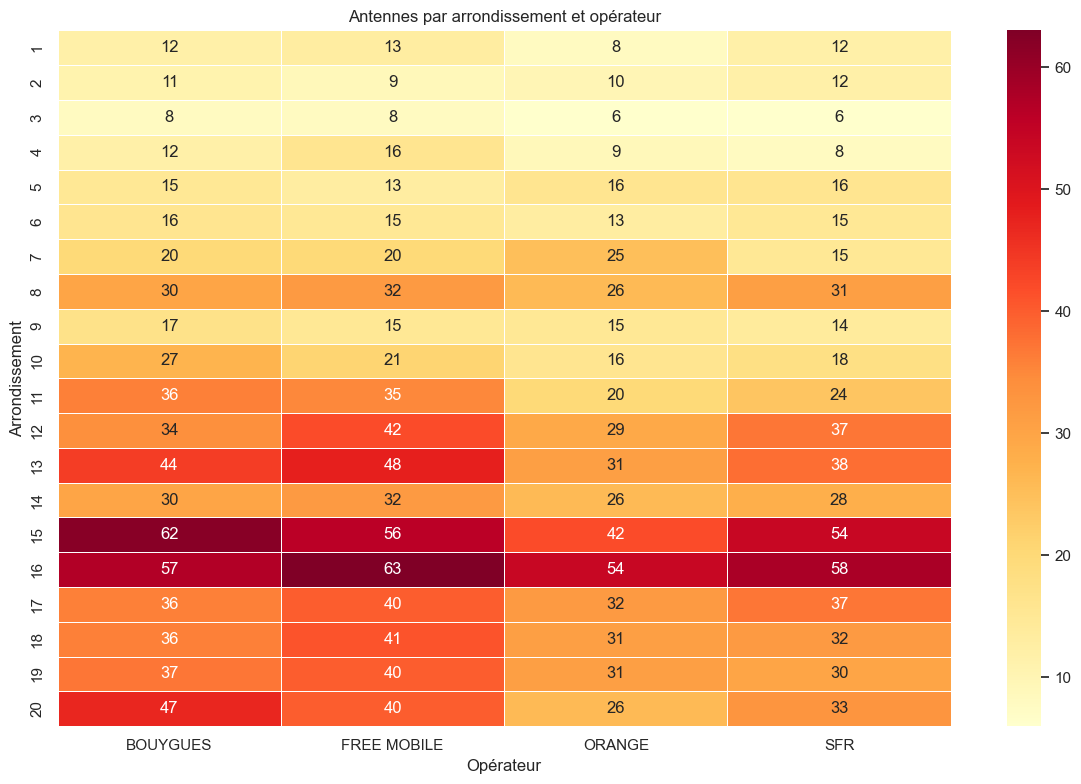


Opérateur dominant par arrondissement :
 arrondissement operateur_dominant
              1        FREE MOBILE
              2                SFR
              3           BOUYGUES
              4        FREE MOBILE
              5             ORANGE
              6           BOUYGUES
              7             ORANGE
              8        FREE MOBILE
              9           BOUYGUES
             10           BOUYGUES
             11           BOUYGUES
             12        FREE MOBILE
             13        FREE MOBILE
             14        FREE MOBILE
             15           BOUYGUES
             16        FREE MOBILE
             17        FREE MOBILE
             18        FREE MOBILE
             19        FREE MOBILE
             20           BOUYGUES


In [10]:
# Heatmap : nb antennes par arrondissement x opérateur
pivot = df.groupby(['arrondissement', 'operateur']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='d', linewidths=0.5)
plt.title('Antennes par arrondissement et opérateur')
plt.xlabel('Opérateur')
plt.ylabel('Arrondissement')
plt.tight_layout()
plt.show()

# Opérateur dominant par arrondissement
dominant = pivot.idxmax(axis=1).reset_index()
dominant.columns = ['arrondissement', 'operateur_dominant']
print('\nOpérateur dominant par arrondissement :')
print(dominant.to_string(index=False))

## 8. Couverture 5G par arrondissement

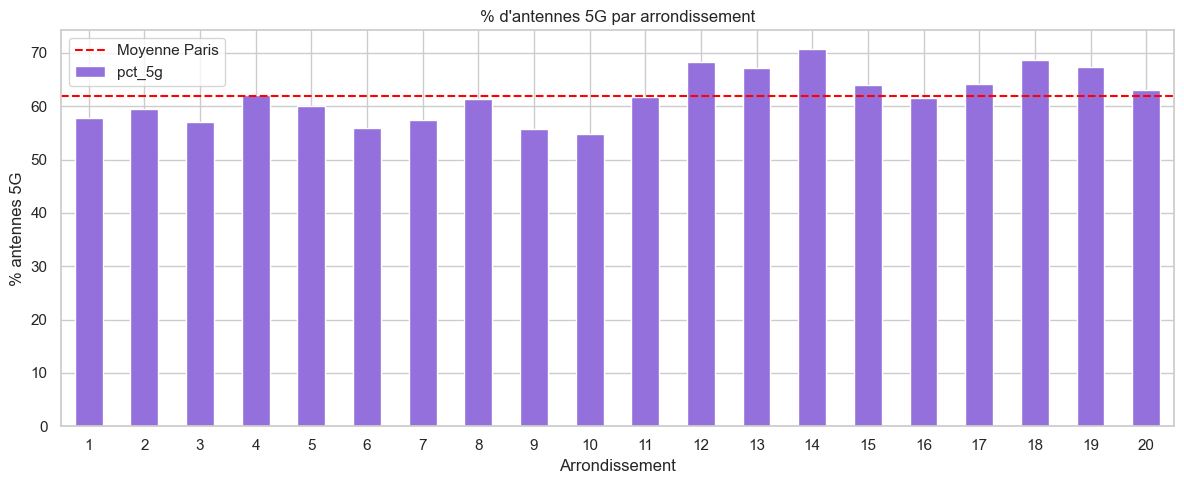

                total  nb_5g  pct_5g
arrondissement                      
1                  45     26    57.8
2                  42     25    59.5
3                  28     16    57.1
4                  45     28    62.2
5                  60     36    60.0
6                  59     33    55.9
7                  80     46    57.5
8                 119     73    61.3
9                  61     34    55.7
10                 82     45    54.9
11                115     71    61.7
12                142     97    68.3
13                161    108    67.1
14                116     82    70.7
15                214    137    64.0
16                232    143    61.6
17                145     93    64.1
18                140     96    68.6
19                138     93    67.4
20                146     92    63.0


In [11]:
df['has_5g'] = df['type'].fillna('').str.contains('5G')

coverage_5g = df.groupby('arrondissement')['has_5g'].agg(
    total='count',
    nb_5g='sum'
)
coverage_5g['pct_5g'] = (coverage_5g['nb_5g'] / coverage_5g['total'] * 100).round(1)

ax = coverage_5g['pct_5g'].plot(kind='bar', color='mediumpurple')
ax.set_title('% d\'antennes 5G par arrondissement')
ax.set_xlabel('Arrondissement')
ax.set_ylabel('% antennes 5G')
ax.axhline(coverage_5g['pct_5g'].mean(), color='red', linestyle='--', label='Moyenne Paris')
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(coverage_5g)

## 9. Évolution des mises en service

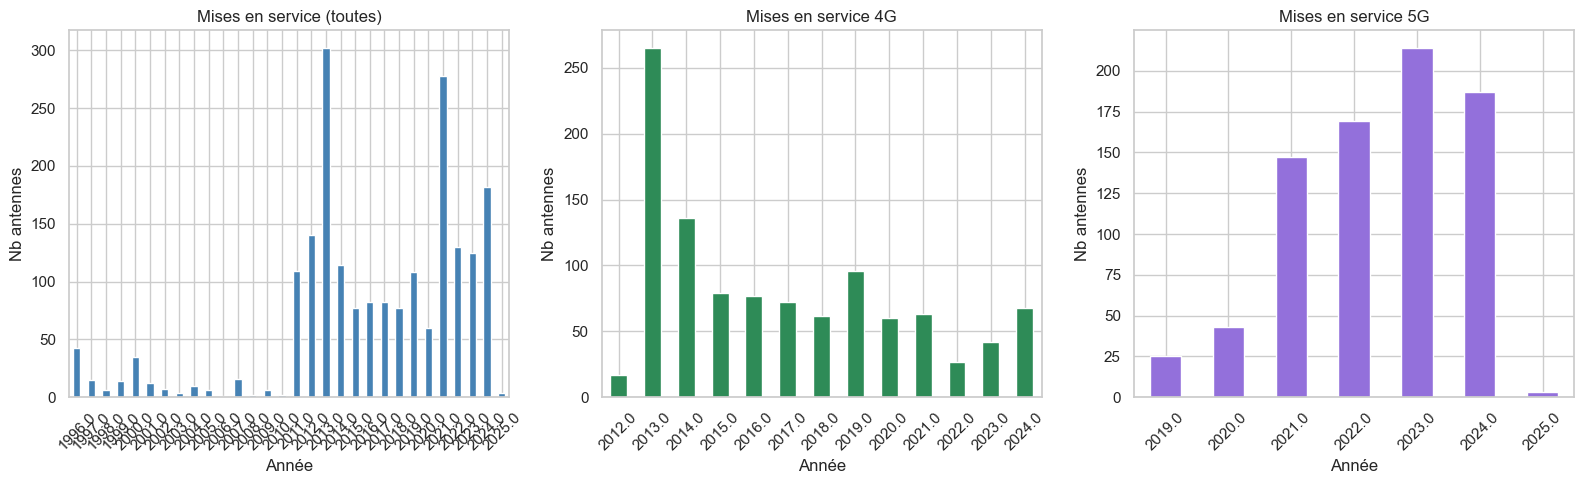

In [12]:
df['annee_serv'] = pd.to_datetime(df['mise_en_serv'], errors='coerce').dt.year
df['annee_4g']   = pd.to_datetime(df['mise_en_serv_4g'], errors='coerce').dt.year
df['annee_5g']   = pd.to_datetime(df['mise_en_serv_5g_3500'], errors='coerce').dt.year

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title, color in zip(
    axes,
    ['annee_serv', 'annee_4g', 'annee_5g'],
    ['Mises en service (toutes)', 'Mises en service 4G', 'Mises en service 5G'],
    ['steelblue', 'seagreen', 'mediumpurple']
):
    counts = df[col].dropna().value_counts().sort_index()
    counts.plot(kind='bar', ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel('Année')
    ax.set_ylabel('Nb antennes')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [16]:
# Conversion
df['mise_en_serv']         = pd.to_datetime(df['mise_en_serv'], errors='coerce')
df['mise_en_serv_4g']      = pd.to_datetime(df['mise_en_serv_4g'], errors='coerce')
df['mise_en_serv_5g_3500'] = pd.to_datetime(df['mise_en_serv_5g_3500'], errors='coerce')

# Extraction année
df['annee_serv'] = df['mise_en_serv'].dt.year
df['annee_4g']   = df['mise_en_serv_4g'].dt.year
df['annee_5g']   = df['mise_en_serv_5g_3500'].dt.year

# Vérification
print(df[['mise_en_serv', 'annee_serv', 'mise_en_serv_4g', 'annee_4g', 'mise_en_serv_5g_3500', 'annee_5g']].head(5))
print(f"\nAnnées serv uniques : {sorted(df['annee_serv'].dropna().unique().astype(int))}")
print(f"Années 5G uniques   : {sorted(df['annee_5g'].dropna().unique().astype(int))}")

  mise_en_serv  annee_serv mise_en_serv_4g  annee_4g mise_en_serv_5g_3500  \
0   2021-08-25      2021.0             NaT       NaN                  NaT   
1   2013-09-16      2013.0      2013-09-16    2013.0           2023-07-18   
2   2017-12-18      2017.0      2017-12-18    2017.0           2023-05-19   
3   2016-06-05      2016.0      2016-06-05    2016.0           2024-05-13   
4   2014-05-27      2014.0      2014-05-12    2014.0           2023-03-27   

   annee_5g  
0       NaN  
1    2023.0  
2    2023.0  
3    2024.0  
4    2023.0  

Années serv uniques : [np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022

In [20]:
df['has_2g'] = df['type'].str.contains('2G', na=False)
df['has_3g'] = df['type'].str.contains('3G', na=False)
df['has_4g'] = df['type'].str.contains('4G', na=False)
df['has_5g'] = df['type'].str.contains('5G', na=False)

print(f"Antennes 2G : {df['has_2g'].sum()} ({df['has_2g'].mean()*100:.1f}%)")
print(f"Antennes 3G : {df['has_3g'].sum()} ({df['has_3g'].mean()*100:.1f}%)")
print(f"Antennes 4G : {df['has_4g'].sum()} ({df['has_4g'].mean()*100:.1f}%)")
print(f"Antennes 5G : {df['has_5g'].sum()} ({df['has_5g'].mean()*100:.1f}%)")

Antennes 2G : 382 (17.6%)
Antennes 3G : 1583 (72.9%)
Antennes 4G : 1582 (72.9%)
Antennes 5G : 1374 (63.3%)


In [21]:
df['adresse'] = df['adresse'].str.strip().str.title()

print("Avant/Après normalisation adresse :")
print(df['adresse'].head(5).tolist())

Avant/Après normalisation adresse :
['157 Boulevard Davout', '159 Avenue De Flandres', '16 Rue Barbet De Jouy', '16 Rue De Cambrai', '163 Rue De Charenton']


## 10. Synthèse

In [ ]:
print('=== SYNTHÈSE EDA ANTENNES RELAIS ===')
print(f'Total antennes             : {len(df):,}')
print(f'Doublons (code_site)       : {doublons}')
print(f'Arrondissements couverts   : {df["arrondissement"].nunique()}')
print(f'Opérateurs                 : {df["operateur"].nunique()}')
print(f'Antennes 5G                : {df["has_5g"].sum()} ({df["has_5g"].mean()*100:.1f}%)')
print(f'\nArrondissement le + équipé : {arr_counts.idxmax()} ({arr_counts.max()} antennes)')
print(f'Arrondissement le - équipé : {arr_counts.idxmin()} ({arr_counts.min()} antennes)')
print(f'\nOpérateur leader           : {op_counts.idxmax()} ({op_counts.max()} antennes)')

=== SYNTHÈSE EDA ANTENNES RELAIS ===
Total antennes             : 2,170
Doublons (code_site)       : 0
Arrondissements couverts   : 20
Opérateurs                 : 4
Antennes 5G                : 1374 (63.3%)

Arrondissement le + équipé : 16 (232 antennes)
Arrondissement le - équipé : 3 (28 antennes)

Opérateur leader           : FREE MOBILE (599 antennes)
